# Final Project NLP

Mateo Galvis L

## 1. Packages

In [ ]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import spacy
import pickle
# Enity extraction
import torch
from transformers import pipeline
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from transformers.pipelines.pt_utils import KeyDataset
from collections import Counter

In [ ]:
from google.colab import drive
# Contect to your drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Read data

In [ ]:
df_news_AI_clean_topics = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/def_news_AI_clean_topics.parquet', engine='pyarrow')

In [ ]:
display(df_news_AI_clean_topics.head(3))

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score,Topic_Number,Topic_Name,Probability
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482,0.205120,9,Cryptocurrency & Financial Trading,0.995980
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736,0.282888,3,Digital Media & Entertainment,0.974883
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811,0.378478,3,Digital Media & Entertainment,0.453399


In [ ]:
print('Initial dataframe shape :', df_news_AI_clean_topics.shape)
print('Columns in the dataframe :', df_news_AI_clean_topics.columns)

Initial dataframe shape : (186029, 18)
Columns in the dataframe : Index(['url', 'date', 'title', 'text', 'year', 'month', 'text_word_count',
       'title_word_count', 'clean_title', 'clean_text',
       'title_word_clean_count', 'text_word_clean_count', 'title_text_clean',
       'title_text_clean_count', 'semantic_score', 'Topic_Number',
       'Topic_Name', 'Probability'],
      dtype='object')


In [ ]:
display(df_news_AI_clean_topics.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186029 entries, 0 to 186028
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   url                     186029 non-null  object        
 1   date                    186029 non-null  datetime64[ns]
 2   title                   186029 non-null  object        
 3   text                    186029 non-null  object        
 4   year                    186029 non-null  int32         
 5   month                   186029 non-null  int32         
 6   text_word_count         186029 non-null  int64         
 7   title_word_count        186029 non-null  int64         
 8   clean_title             186029 non-null  object        
 9   clean_text              186029 non-null  object        
 10  title_word_clean_count  186029 non-null  int64         
 11  text_word_clean_count   186029 non-null  int64         
 12  title_text_clean        186029

None

In [ ]:
# 1. Check for GPU (highly recommended for 50k articles)
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: GPU


In [ ]:
# Do a sample of 10% of the data to understand the process
#df_news_AI_clean_topics = df_news_AI_clean_topics.sample(frac=0.05, random_state=97)

In [ ]:
# Check missing values
print('Number of missing values:', df_news_AI_clean_topics['title_text_clean'].isna().sum())
print(len(df_news_AI_clean_topics))

Number of missing values: 0
186029


## 3. Enity extraction

In [ ]:
# bert-base-NER selected model
# bert-base-NER is a fine-tuned BERT model that is ready to use for Named Entity Recognition and achieves state-of-the-art performance for the NER task.
# It has been trained to recognize four types of entities: location (LOC), organizations (ORG), person (PER) and Miscellaneous (MISC).

# Model 1: "dslim/bert-base-NER"
# Model 2: "djagatiya/ner-bert-base-cased-ontonotesv5-englishv4"


In [ ]:
# 1. Load a high-performance base (e.g., dslim/bert-base-NER or a ModernBERT variant)
#model_name = "dslim/bert-base-NER"
#tokenizer = AutoTokenizer.from_pretrained(model_name)
#model = AutoModelForTokenClassification.from_pretrained(model_name)

# 2. Create the NLP pipeline
#nlp = pipeline("ner",
#               model=model,
#               tokenizer=tokenizer,
#               aggregation_strategy="simple")

# 3. Extract entities
#entities = nlp(df_news_AI_clean_topics['title_text_clean'].tolist())

In [ ]:
%%time
model_name = "djagatiya/ner-bert-base-cased-ontonotesv5-englishv4"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)
run = False
if run:
  #aggregation_strategy="simple" automatically groups "B-ORG" and "I-ORG" into one "ORG" word.
  ner_pipe = pipeline(
      "ner",
      model=model,
      aggregation_strategy="simple",
      tokenizer=tokenizer,
      device=device,
      batch_size=128
  )

  # 3. Transform pandas dataframe into Hugging Face Dataset
  hf_dataset_entity = Dataset.from_pandas(df_news_AI_clean_topics)

  # 4. Run Batch Inference
  print("Starting extraction... This might take a while depending on your hardware.")

  extracted_results = []
  for output in ner_pipe(KeyDataset(hf_dataset_entity, "title_text_clean")):
      extracted_results.append(output)
  print("Extraction complete!")

  # save result
  file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/entity_extraction.pkl"
  with open(file_path, "wb") as f:
    pickle.dump(extracted_results, f)
  print(f"Successfully saved to {file_path}")
# load previuos result
else:
  file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/entity_extraction.pkl"
  with open(file_path, "rb") as f:
    extracted_results = pickle.load(f)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/431M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: djagatiya/ner-bert-base-cased-ontonotesv5-englishv4
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CPU times: user 7.91 s, sys: 2.87 s, total: 10.8 s
Wall time: 18 s


In [ ]:
  # Save coherence_scores
#file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/entity_extraction.pkl"
#with open(file_path, "wb") as f:
#    pickle.dump(extracted_results, f)
#print(f"Successfully saved to {file_path}")

In [ ]:
# 1. Define the specific labels you want to keep
target_labels = ['ORG', 'PRODUCT']
filtered_entities = []

# 2. Filter the entities list
# We check if the 'entity_group' of each item matches our target labels
for i in range(0, len(extracted_results)):
  filtered_entity = [ent for ent in extracted_results[i] if ent['entity_group'] in target_labels]
  filtered_entities.append(filtered_entity)

In [ ]:
# Clean format to extarct in document level the word and entity
dict_filtered_entities = {'index_doc':[], 'word':[], 'entity':[],'frenqency':[]}

# Iterate
for i in range(0, len(filtered_entities)):
  current_doc = filtered_entities[i]
  dict_filtered_entities['index_doc'].append(i)

  # create list words and entity_group
  list_words = []
  list_entities = []
  for ent in current_doc:
    if(len(ent['word'])>1):
      list_words.append(ent['word'])
      list_entities.append(ent['entity_group'])

  # Calculate frequency
  word_counts = Counter(list_words)
  frenqency_words = list(word_counts.values())

  # Keep only unique words and entity
  seen = set()
  unique_words = []
  unique_entities = []
  for w, e in zip(list_words, list_entities):
    if w not in seen:
        unique_words.append(w)
        unique_entities.append(e)
        seen.add(w)

  # Add to a dataframe
  dict_filtered_entities['word'].append(unique_words)
  dict_filtered_entities['entity'].append(unique_entities)
  dict_filtered_entities['frenqency'].append(frenqency_words)


# Transfrom dictonary into a dataframe
df_filtered_entities = pd.DataFrame(dict_filtered_entities)
display(df_filtered_entities.head(10))


,index_doc,word,entity,frenqency
0,0,"[##B, ##works Research, BA]","[ORG, ORG, ORG]","[1, 1, 1]"
1,1,"[Werner, Dream Machine]","[ORG, PRODUCT]","[1, 1]"
2,2,"[this Boing Boing ' s Shop, Cha, GPT - 4, Goog...","[ORG, ORG, PRODUCT, ORG, PRODUCT, ORG, PRODUCT...","[1, 1, 2, 2, 1, 1, 1, 1, 1]"
3,3,"[Fund, de China, China, Baidu]","[ORG, ORG, ORG, ORG]","[1, 1, 1, 1]"
4,4,"[Microsoft, ##vidia, Empower Develo, Windows A...","[ORG, ORG, ORG, PRODUCT, PRODUCT, PRODUCT, ORG...","[8, 3, 1, 5, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, ..."
5,5,"[Google, Open, ##S, ##nce, Bar, Gemini, ##I, G...","[ORG, ORG, ORG, ORG, PRODUCT, ORG, ORG, ORG, O...","[6, 4, 1, 1, 5, 7, 2, 1, 1, 1]"
6,6,"[Zoom Expands, Companion, ##ccelerator, Zoom V...","[PRODUCT, PRODUCT, PRODUCT, ORG, PRODUCT, PROD...","[1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7,7,[Industry],[ORG],[1]
8,8,[],[],[]
9,9,"[Rob, AG, ##modo, Re, ##uters, Big Tech, OpenA...","[PRODUCT, ORG, ORG, ORG, ORG, ORG, ORG, ORG, O...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


In [57]:
# Export consolidate parquet
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/df_filtered_entities.parquet"
df_filtered_entities.to_parquet(file_path, engine='auto')

### 3.1 Top Enity General

In [ ]:
# Top 20 most common entities
df_exploded = df_filtered_entities.explode(['word', 'entity', 'frenqency'])

# 2. Ensure the frequency column is treated as numeric integers
df_exploded['frenqency'] = pd.to_numeric(df_exploded['frenqency'])

# 3. Group by 'word' and 'entity', sum the frequencies
frenq_entities = (df_exploded
                   .groupby(['word', 'entity'], as_index=False)['frenqency']
                   .sum()
                   .sort_values(by='frenqency', ascending=False))

# 4. Reset the index for a clean output
frenq_entities = frenq_entities.reset_index(drop=True)
#total
total = frenq_entities['frenqency'].sum()
frenq_entities['percentage'] = frenq_entities['frenqency'] / total * 100

display(frenq_entities)

,word,entity,frenqency,percentage
0,Google,ORG,53603.0,2.298477
1,Microsoft,ORG,51985.0,2.229098
2,OpenAI,ORG,50664.0,2.172454
3,AI,ORG,38622.0,1.656098
4,Cha,ORG,35735.0,1.532304
...,...,...,...,...
236313,E + D (,ORG,1.0,0.000043
236314,E - 208,PRODUCT,1.0,0.000043
236315,E - 7,PRODUCT,1.0,0.000043
236316,E - A,PRODUCT,1.0,0.000043


/tmp/ipykernel_10120/971191819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')


,word,entity,frenqency
0,Google,ORG,53603.0
1,Microsoft,ORG,51985.0
2,OpenAI,ORG,50664.0
3,AI,ORG,38622.0
4,Apple,ORG,26393.0
5,Open,ORG,25089.0
6,PR,ORG,24688.0
7,Amazon,ORG,15926.0
8,Nvidia,ORG,15313.0
9,PRNewswire,ORG,12920.0


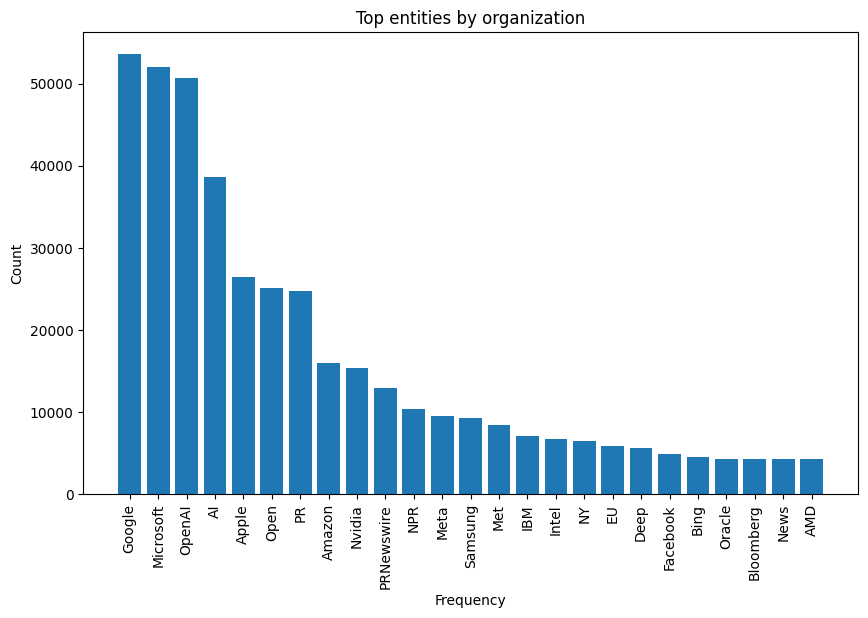

In [ ]:
# Filter only ORG
df_aux = frenq_entities[frenq_entities['entity']=='ORG']
df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')
df_aux = df_aux.groupby(['word','entity'])['frenqency'].sum().reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)

# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='ME']
df_aux = df_aux[df_aux['word']!='Re']
df_aux = df_aux[df_aux['word']!='An']
df_aux = df_aux[df_aux['word']!='PRNews']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='Cha']
df_aux.reset_index(drop=True, inplace=True)


df_aux = df_aux.head(25)
display(df_aux)

# bar plot
plt.figure(figsize=(10, 6))
plt.bar(df_aux['word'], df_aux['frenqency'])
plt.title("Top entities by organization")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_10120/3411274522.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##A', 'AI')


,word,entity,frenqency
12465,AI,PRODUCT,6670.0
22320,Gemini,PRODUCT,6170.0
16912,Cha,PRODUCT,4841.0
21615,GP,PRODUCT,3937.0
21637,GPT - 4,PRODUCT,2602.0
39499,iPhone,PRODUCT,1355.0
21726,GPU,PRODUCT,1020.0
38231,Windows 11,PRODUCT,961.0
15849,Bing,PRODUCT,892.0
13299,AII,PRODUCT,880.0


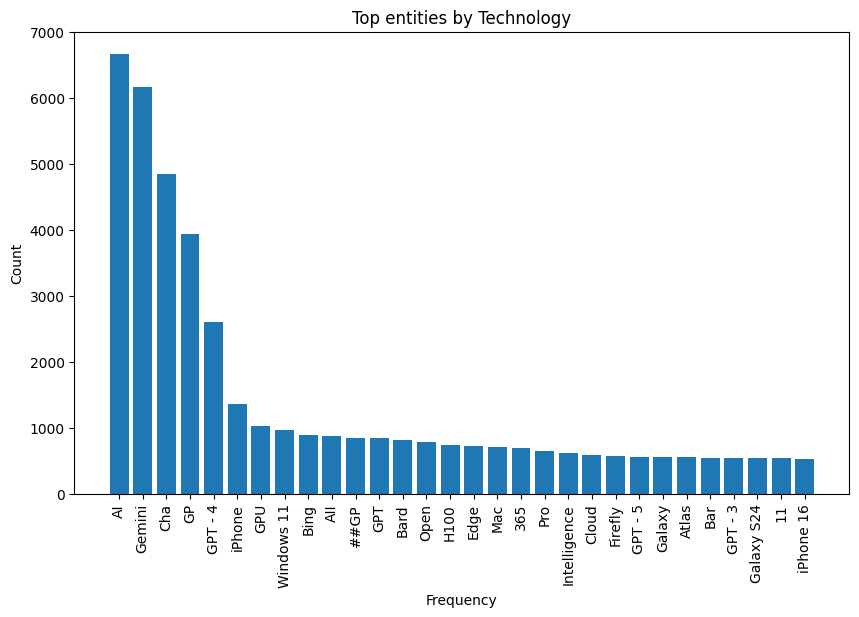

In [40]:
# Filter only product
df_aux = frenq_entities[frenq_entities['entity']=='PRODUCT']

df_aux['word'] = df_aux['word'].str.replace('##A', 'AI')
df_aux = df_aux.groupby(['word','entity'])['frenqency'].sum().reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)


# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='##t']
df_aux = df_aux[df_aux['word']!='the']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##3']
df_aux = df_aux[df_aux['word']!='##T']
df_aux = df_aux[df_aux['word']!='Pi']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='##2']
df_aux = df_aux[df_aux['word']!='##VI']
df_aux = df_aux[df_aux['word']!='Co']
df_aux = df_aux[df_aux['word']!='So']
df_aux = df_aux[df_aux['word']!='Re']

df_aux = df_aux.head(30)
display(df_aux)

plt.figure(figsize=(10, 6))
plt.bar(df_aux['word'], df_aux['frenqency'])
plt.title("Top entities by Technology")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

### 3.2 Enity by topic modeling

In [23]:
# Merge both dataframe
initial_rows = len(df_news_AI_clean_topics)
df_news_AI_entity = df_news_AI_clean_topics.copy()
df_news_AI_entity['index'] = df_news_AI_clean_topics.index
df_news_AI_entity = pd.merge(df_news_AI_clean_topics, df_filtered_entities, left_on='index', right_on='index_doc', how='inner')
final_rows = len(df_news_AI_entity)
print(f'Initial rows: {initial_rows}, Final rows: {final_rows}')

Initial rows: 186029, Final rows: 186029


/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
13099,Google,ORG,17900.0
7707,Apple,ORG,7031.0
20883,Samsung,ORG,5636.0
16910,Microsoft,ORG,5051.0
12739,Gemini,PRODUCT,3784.0
12406,Galaxy,ORG,2257.0
24693,Windows,ORG,1762.0
18438,Open,ORG,1370.0


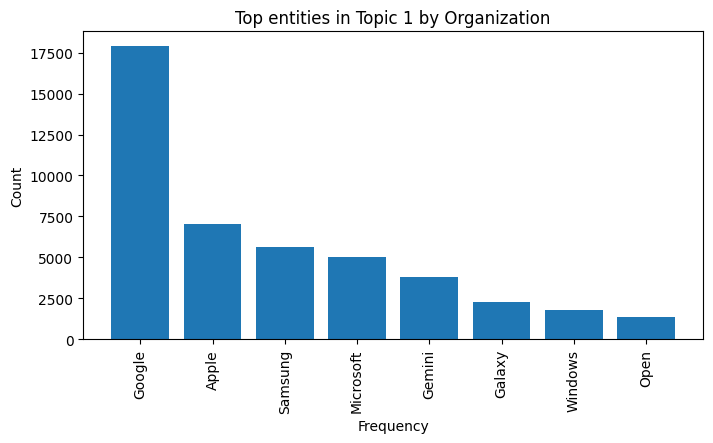

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
2684,FDA,ORG,678.0
2856,Galaxy,PRODUCT,480.0
4679,S24,PRODUCT,379.0
1705,Alphabet,ORG,289.0
1830,Atlas,PRODUCT,236.0
5754,iOS 18,PRODUCT,235.0
3631,Link,ORG,129.0
5585,WhatsApp,ORG,126.0


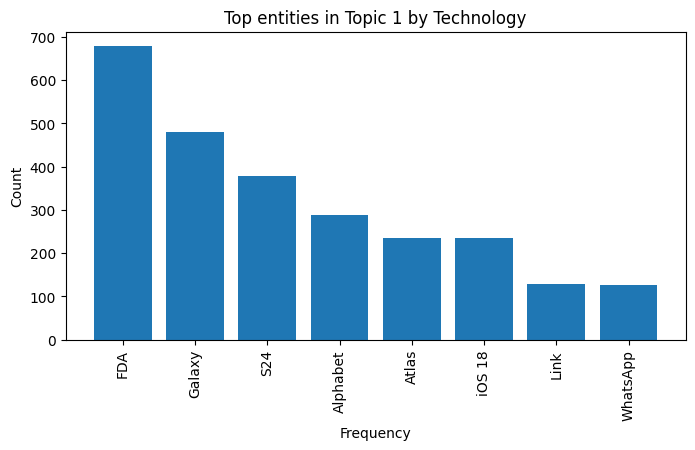

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
7792,Google,ORG,5869.0
11076,OpenAI,ORG,4284.0
10077,Microsoft,ORG,4197.0
3389,AI,ORG,2155.0
11065,Open,ORG,2124.0
10424,NPR,ORG,1358.0
4189,Associated Press,ORG,1166.0
5817,Congress,ORG,1116.0


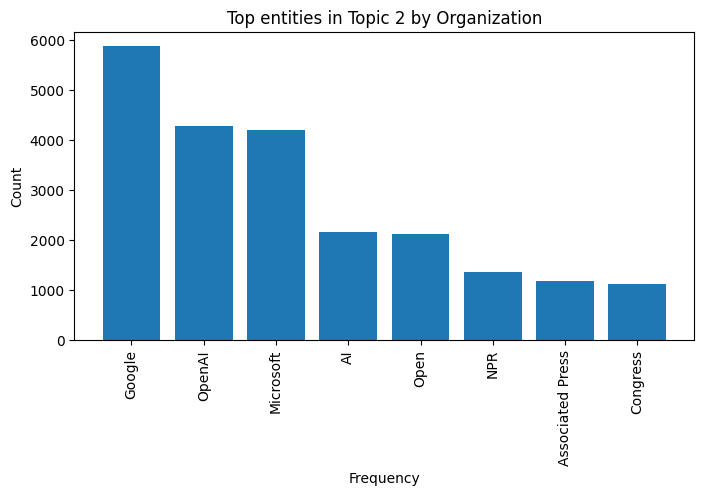

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
1555,Facebook,ORG,645.0
3228,University,ORG,536.0
2657,Reuters,ORG,266.0
978,BBC,ORG,226.0
939,Army,ORG,75.0
1274,College,ORG,69.0
2798,Signal,ORG,64.0
806,AIpp,ORG,63.0


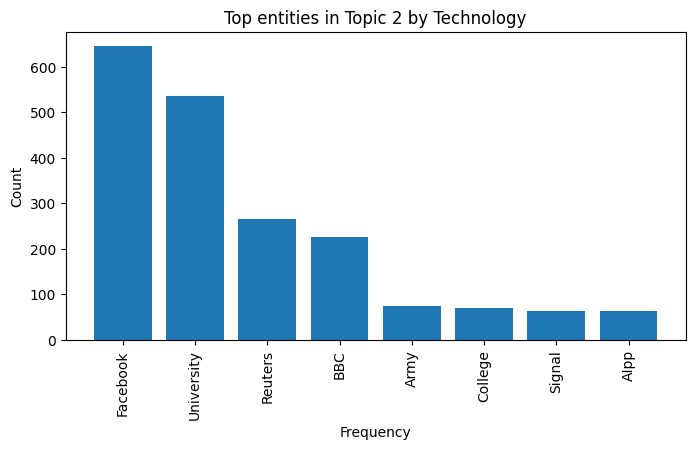

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
21399,Nvidia,ORG,11127.0
19941,Microsoft,ORG,10957.0
21772,OpenAI,ORG,7034.0
15756,Google,ORG,6956.0
9331,Apple,ORG,5823.0
7681,AI,ORG,5077.0
9051,Amazon,ORG,4892.0
17381,Intel,ORG,3658.0


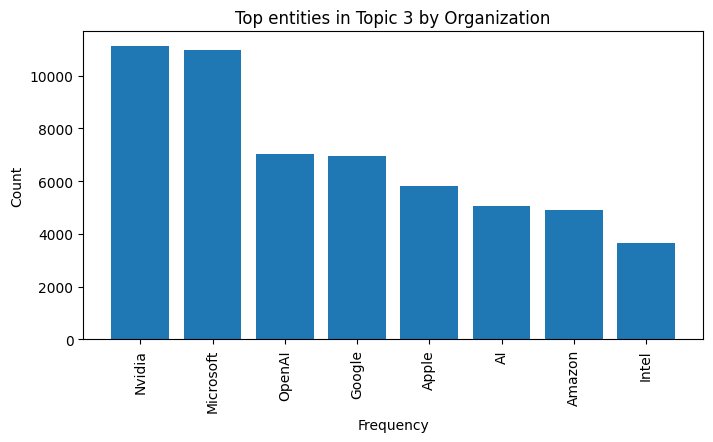

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
2444,Bloomberg,ORG,1251.0
3486,GP,ORG,968.0
2586,CNBC,ORG,739.0
3741,H100,PRODUCT,581.0
5814,SoftBank,ORG,432.0
4755,NVIDIA,ORG,410.0
1809,AI,ORG,397.0
4600,Microsoft Corp.,ORG,175.0


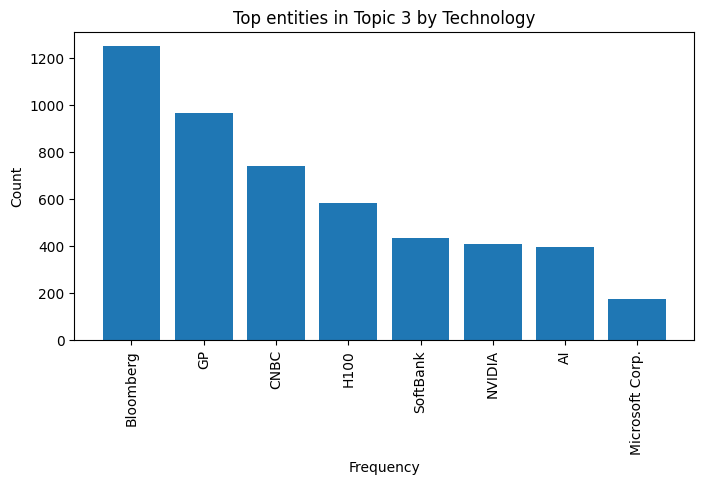

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
18817,Microsoft,ORG,3150.0
14592,Google,ORG,2883.0
7006,AI,ORG,2128.0
8219,Amazon,ORG,2079.0
8449,Apple,ORG,1947.0
20525,OpenAI,ORG,1738.0
18678,Met,ORG,1602.0
20514,Open,ORG,1571.0


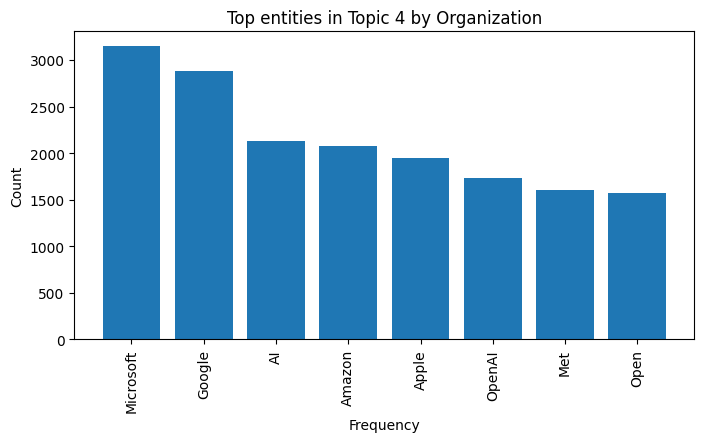

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
2949,EU,ORG,467.0
2552,Co,PRODUCT,349.0
2764,Deep,ORG,310.0
5576,Steam,ORG,246.0
3657,IP,ORG,238.0
3711,India,ORG,213.0
1978,Associated Press,ORG,188.0
4539,NBA,ORG,186.0


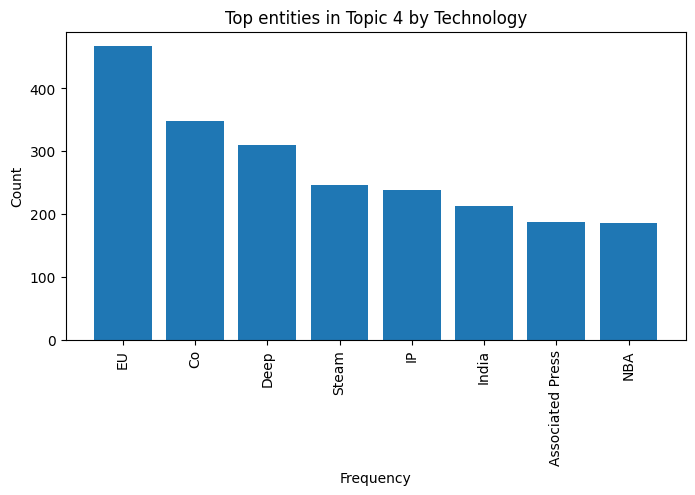

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
14063,NPR,ORG,8140.0
13465,Microsoft,ORG,4655.0
15020,OpenAI,ORG,3381.0
10106,Google,ORG,2376.0
15006,Open,ORG,2094.0
5109,Amazon,ORG,2060.0
4484,AI,ORG,1677.0
14013,NFL,ORG,1451.0


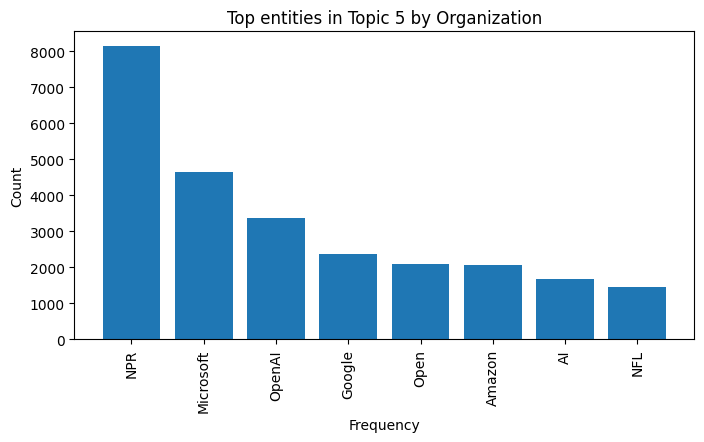

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
1258,Associated Press,ORG,524.0
4611,What,ORG,469.0
1473,Business,ORG,380.0
3902,Sports,ORG,281.0
4567,Walmart,ORG,236.0
3040,Mint,ORG,232.0
2422,Home,ORG,135.0
517,##ive,ORG,128.0


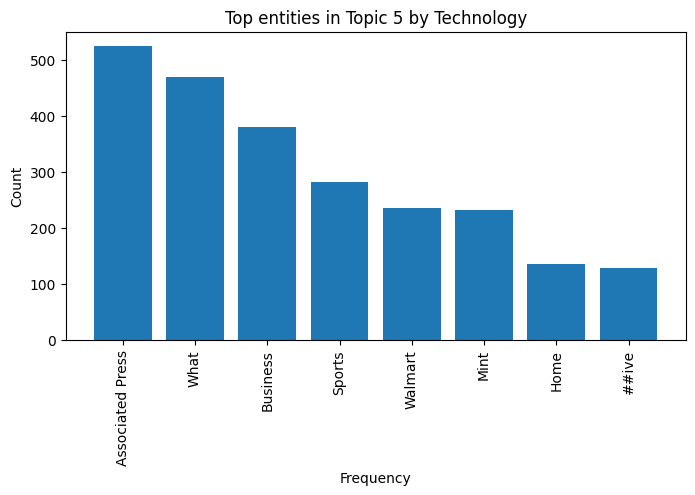

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
15098,OpenAI,ORG,10390.0
10961,Google,ORG,6986.0
13867,Microsoft,ORG,6213.0
15073,Open,ORG,5817.0
5187,AI,ORG,2378.0
5716,Adobe,ORG,2359.0
13773,Meta,ORG,1886.0
13770,Met,ORG,1866.0


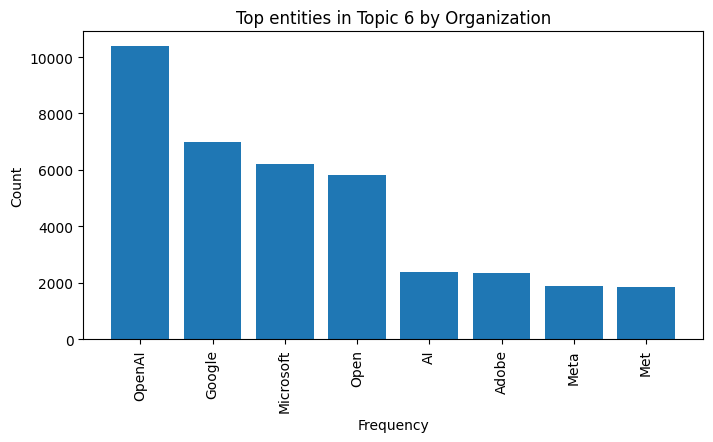

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
2317,Gemini,PRODUCT,843.0
3183,NPR,ORG,621.0
3414,PRNews,ORG,516.0
2208,Forbes,ORG,399.0
2268,GPT,PRODUCT,357.0
3892,So,ORG,300.0
526,##ic,ORG,272.0
1885,DALL - E,PRODUCT,267.0


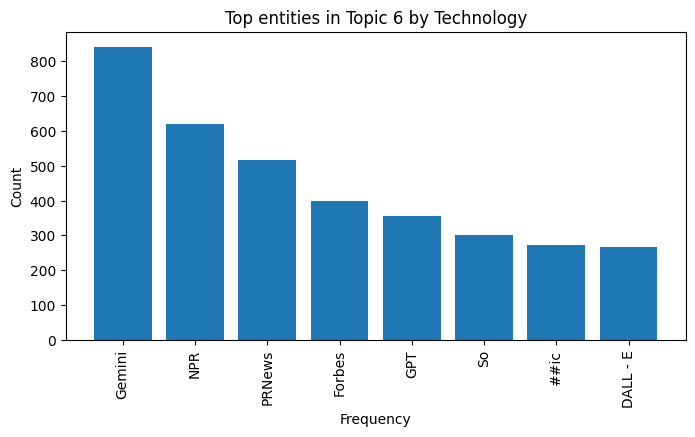

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
16453,OpenAI,ORG,14777.0
6814,Apple,ORG,7533.0
15159,Microsoft,ORG,6991.0
16439,Open,ORG,5314.0
5742,AI,ORG,5121.0
12055,Google,ORG,3450.0
16221,Nvidia,ORG,2389.0
15674,NY,ORG,1868.0


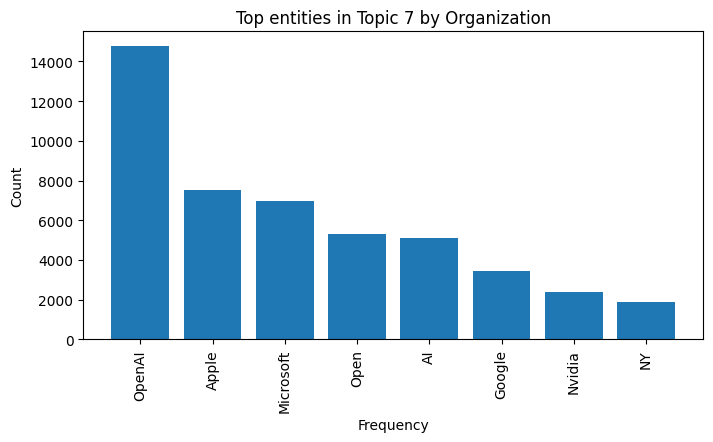

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
3499,Na,ORG,900.0
3445,Musk,ORG,680.0
3544,News,ORG,436.0
1422,Alpha,ORG,417.0
2882,Inc,ORG,356.0
3450,NASDA,ORG,320.0
1435,Altman,ORG,143.0
3738,Palantir Technologies,ORG,137.0


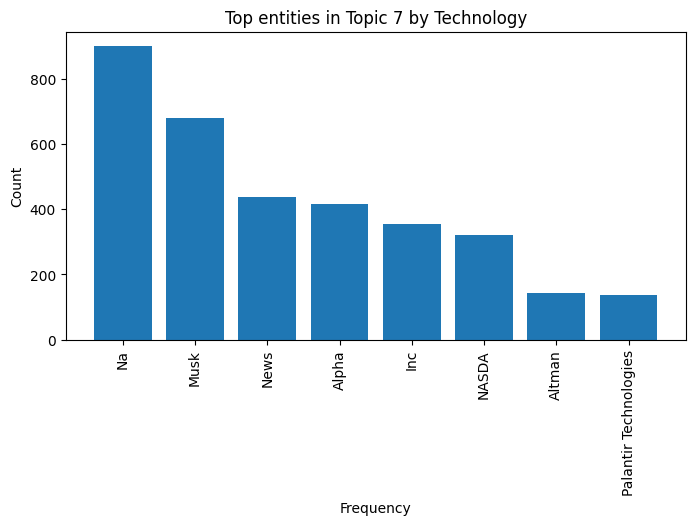

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
7730,AI,ORG,10105.0
26594,OpenAI,ORG,6760.0
24199,Microsoft,ORG,6156.0
18562,Google,ORG,3678.0
15856,EU,ORG,3462.0
26563,Open,ORG,2372.0
26949,PRNewswire,ORG,1807.0
19910,IBM,ORG,1382.0


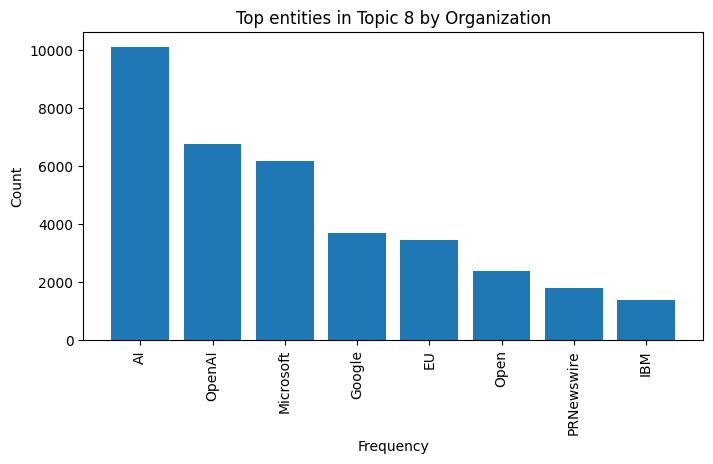

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
8642,the,ORG,675.0
2361,An,ORG,571.0
3936,European Union,ORG,471.0
5423,ME,ORG,378.0
3780,ET,ORG,350.0
5719,Mo,ORG,327.0
3983,FDA,ORG,296.0
5806,NE,ORG,169.0


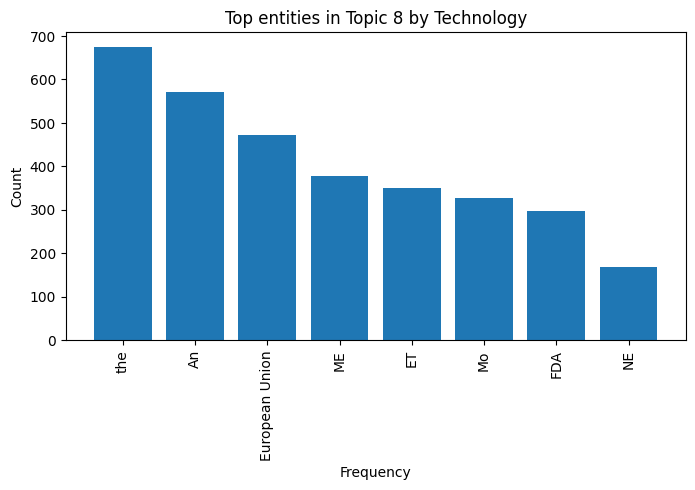

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
34132,PRNewswire,ORG,9137.0
11551,AI,ORG,8499.0
34033,PRNews,ORG,4903.0
30922,Microsoft,ORG,4221.0
24624,Google,ORG,3059.0
26167,IBM,ORG,2118.0
24646,Google Cloud,ORG,2034.0
33613,Oracle,ORG,1952.0


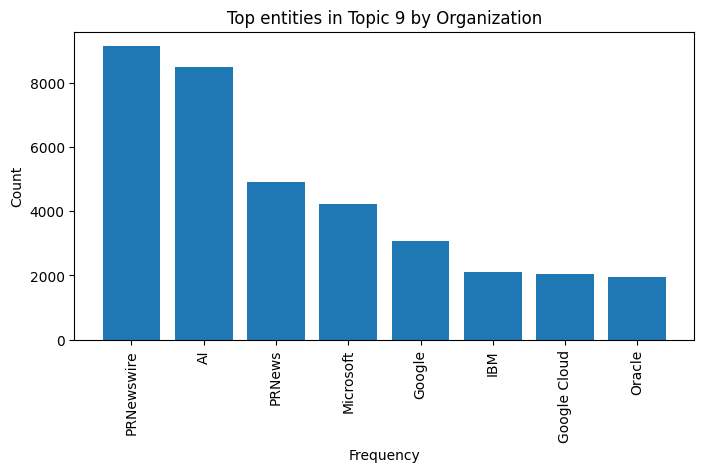

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
8666,Sa,ORG,1005.0
7730,Open,ORG,812.0
4663,Data,ORG,748.0
9419,Te,ORG,629.0
6973,Ma,ORG,603.0
7266,Mo,ORG,549.0
7139,Met,ORG,505.0
556,##VI,PRODUCT,499.0


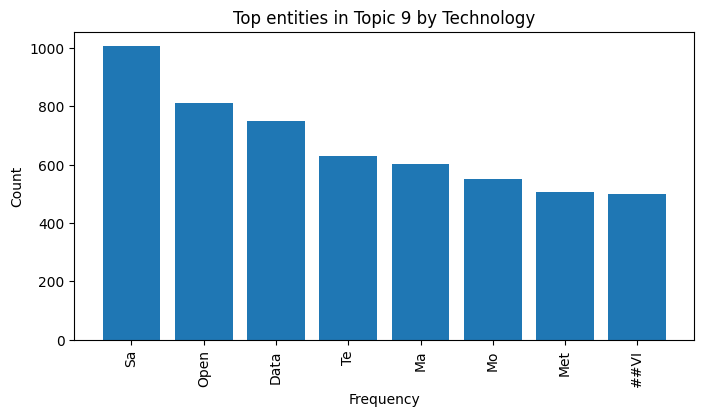

/tmp/ipykernel_10120/1772729491.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']


,word,entity,frenqency
13338,ME,ORG,3139.0
4560,AI,ORG,2708.0
14410,NY,ORG,2178.0
9892,Fiat,ORG,823.0
15213,PA,ORG,776.0
8368,Cry,ORG,706.0
6658,Bit,ORG,679.0
9894,Fiat Cal,ORG,602.0


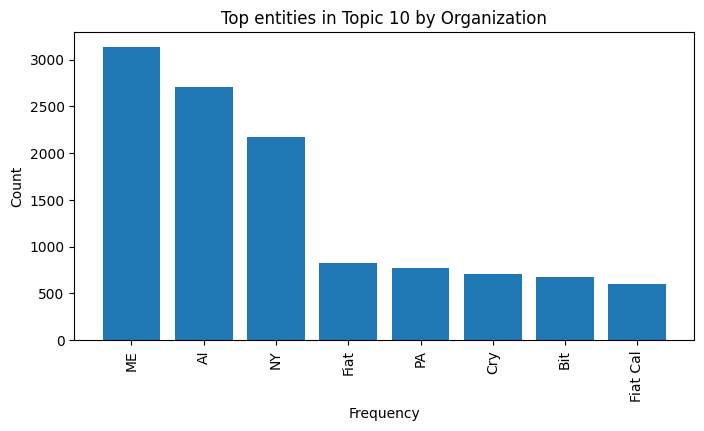

/tmp/ipykernel_10120/1772729491.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']


,word,entity,frenqency
1915,Con,ORG,249.0
3439,Pa,ORG,218.0
132,##N,ORG,192.0
858,##tor,ORG,168.0
1110,AIDI,ORG,153.0
3938,Sleep,ORG,136.0
2727,Intelligence,ORG,128.0
413,##ets,ORG,127.0


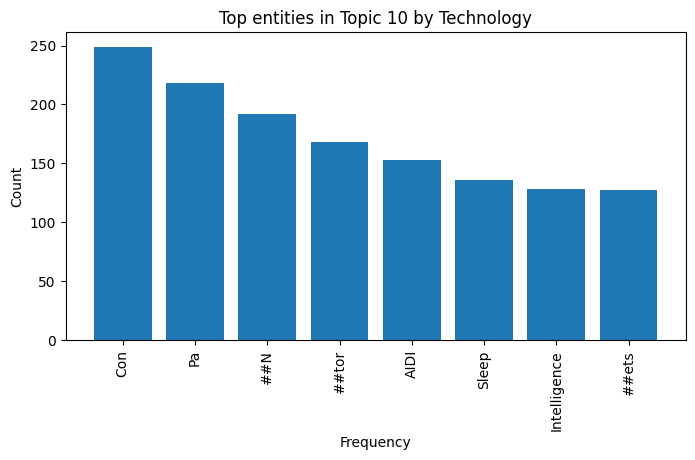

In [56]:
def calculate_entetis_by_product(topic, title):
  # Filter by topic
  df_aux = df_news_AI_entity[df_news_AI_entity['Topic_Number']==topic]

  # Do the explotion
  df_exploded = df_aux.explode(['word', 'entity', 'frenqency'])

  # 2. Ensure the frequency column is treated as numeric integers
  df_exploded['frenqency'] = pd.to_numeric(df_exploded['frenqency'])

  # 3. Group by 'word' and 'entity', sum the frequencies
  frenq_entities_bytopic = (df_exploded
                    .groupby(['word', 'entity'], as_index=False)['frenqency']
                    .sum()
                    .sort_values(by='frenqency', ascending=False))

  # 4. Reset the index for a clean output
  frenq_entities_bytopic = frenq_entities_bytopic.reset_index(drop=True)
  #total
  total = frenq_entities_bytopic['frenqency'].sum()
  frenq_entities_bytopic['percentage'] = frenq_entities_bytopic['frenqency'] / total * 100


  # remove noise tokens
  stop_tokens = ['##t','##xe','##3','Per','Cha','PR','##uters','##TC',
                 '##ripps News','Ex','##GP','##V','##s','##C','In','##ews']

  for stop_token in stop_tokens:
    frenq_entities_bytopic = frenq_entities_bytopic[frenq_entities_bytopic['word']!=stop_token]
  #Remplace some words
  frenq_entities_bytopic['word'] = frenq_entities_bytopic['word'].str.replace('##A', 'AI')
  frenq_entities_bytopic['word'] = frenq_entities_bytopic['word'].str.replace('##vidia','Nvidia')


  # Filter only product
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='ORG']
  df_aux = df_aux.groupby(['word','entity'])['frenqency'].sum().reset_index()
  df_aux = df_aux.sort_values(by='frenqency', ascending=False)

  df_aux = df_aux.head(8)
  display(df_aux)

  plt.figure(figsize=(8, 4))
  plt.bar(df_aux['word'], df_aux['frenqency'])
  title_pro = title + ' Organization'
  plt.title(title_pro)
  plt.xlabel("Frequency")
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()


  # Filter only product
  df_aux = frenq_entities_bytopic[frenq_entities['entity']=='PRODUCT']
  df_aux = df_aux.groupby(['word','entity'])['frenqency'].sum().reset_index()
  df_aux = df_aux.sort_values(by='frenqency', ascending=False)

  df_aux = df_aux.head(8)
  display(df_aux)

  plt.figure(figsize=(8, 4))
  plt.bar(df_aux['word'], df_aux['frenqency'])
  title_tec = title + ' Technology'
  plt.title(title_tec)
  plt.xlabel("Frequency")
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()

# Called the function
for topic in range(0,10):
  title = 'Top entities in Topic '+str(topic+1)+' by'
  calculate_entetis_by_product(topic, title)